# Comparison of Generative Data Sampling

Code is from [This Github Repo](https://github.com/Diyago/Tabular-data-generation/tree/master) to save time

basically will be running all four options and comparing outputs to show how these vary and if there is noticable difference for the quality of the data and other implications for synthetic data to improve dataset size (like if that causes bias?)


In [ ]:
import kagglehub, os, ipaddress
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from dotenv import load_dotenv
from huggingface_hub import login
import joblib
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Load variables from .env
load_dotenv()

# Get the token and login
hf_token = os.getenv("HF_Token")
if hf_token:
    login(token=hf_token)
else:
    print("Warning: No Hugging Face token found in .env file.")
    
# Download latest version to compare with the two generated datasets from models
path = kagglehub.dataset_download(
    "munaalhawawreh/xiiotid-iiot-intrusion-dataset")

print("Path to dataset files:", path)
print(path)
df = pd.read_csv(path + "\\X-IIoTID dataset.csv", skipinitialspace=True)


# 1. Basic Cleaning: Strip whitespace from columns and string values
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Universal IP & Port Normalizer (Handles IPv4, IPv6, ?, -, and Ports)


def universal_to_numeric(val):
    val = str(val).strip()
    if val in ['?', '-', '', 'None']:
        return 0
    try:
        # If it looks like an IP, convert to int
        if '.' in val or ':' in val:
            return int(ipaddress.ip_address(val))
        # Otherwise, treat as a standard number
        return int(float(val))
    except:
        return 0


for col in ['Scr_IP', 'Des_IP', 'Scr_port', 'Des_port']:
    df[col] = df[col].apply(universal_to_numeric)

# 3. Timestamp Fix (Convert Unix to Numeric safely)
df['Timestamp'] = pd.to_numeric(
    df['Timestamp'], errors='coerce').fillna(0).astype('int32')
df['Time'] = pd.to_datetime(df['Timestamp'], unit='s')
df.drop(columns=['Timestamp'], inplace=True)
# 4. Boolean/Flag Mapping (TRUE/FALSE strings or actual Bools -> 0/1)
bool_cols = [
    'is_syn_only', 'Is_SYN_ACK', 'is_pure_ack', 'is_with_payload',
    'FIN or RST', 'Bad_checksum', 'is_SYN_with_RST', 'anomaly_alert'
]
for col in bool_cols:
    if col in df.columns:
        # Map strings if they exist, otherwise force to int
        if df[col].dtype == 'object':
            df[col] = df[col].str.upper().map(
                {'TRUE': 1, 'FALSE': 0, '-': 0, '?': 0})
        df[col] = df[col].fillna(0).astype('int32')

# 5. Mass Numeric Conversion for Metrics (Duration, Bytes, CPU stats, etc.)
# We replace '?' and '-' with 0 first
df.replace(['?', '-'], 0, inplace=True)
cat_cols = ['Protocol', 'Service', 'class1', 'class2', 'class3', 'Scr_IP', 'Des_IP']
encoders = {}
# 6. Categorical Cleanup
for col in ['Protocol', 'Service', 'Scr_IP', 'Des_IP']:
    df[col] = df[col].replace(0, 'unknown').astype(str)
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        # Ensure everything is a string before encoding to avoid mixed-type errors
        df[col] = le.fit_transform(df[col].astype(str)).astype('float32')
        encoders[col] = le

joblib.dump(encoders, 'label_encoders.joblib')
# 3. Final safety check: ensure NO strings remain in the numeric features
# (This prevents the 'udp' error once and for all)
for col in df.columns:
    if df[col].dtype == 'object':
        # If any stray strings exist, force them to numeric or drop
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
# Identify all columns that should be numeric (excluding categorical labels)

numeric_cols = [c for c in df.columns if c not in cat_cols + ['Date']]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype('float32')

# 7. Final Drop
df.drop(columns=['Date'], inplace=True)
df.to_csv('cleaned_original_data.csv', index=False)
df.info()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Path to dataset files: C:\Users\antho\.cache\kagglehub\datasets\munaalhawawreh\xiiotid-iiot-intrusion-dataset\versions\1
C:\Users\antho\.cache\kagglehub\datasets\munaalhawawreh\xiiotid-iiot-intrusion-dataset\versions\1


C:\Users\antho\AppData\Local\Temp\ipykernel_19040\2069004606.py:24: DtypeWarning: Columns (0: Timestamp, 1: Scr_port, 2: Des_port, 3: missed_bytes, 4: anomaly_alert) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "\\X-IIoTID dataset.csv", skipinitialspace=True)


<class 'pandas.DataFrame'>
RangeIndex: 820834 entries, 0 to 820833
Data columns (total 67 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Scr_IP                       820834 non-null  float32
 1   Scr_port                     820834 non-null  float32
 2   Des_IP                       820834 non-null  float32
 3   Des_port                     820834 non-null  float32
 4   Protocol                     820834 non-null  float32
 5   Service                      820834 non-null  float32
 6   Duration                     820834 non-null  float32
 7   Scr_bytes                    820834 non-null  float32
 8   Des_bytes                    820834 non-null  float32
 9   Conn_state                   820834 non-null  float32
 10  missed_bytes                 820834 non-null  float32
 11  is_syn_only                  820834 non-null  float32
 12  Is_SYN_ACK                   820834 non-null  float32
 13  is_pure_ac

In [2]:
df.head()

,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,Des_bytes,Conn_state,...,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3,Time
0,21.0,49278.0,64.0,80.0,1.0,4.0,0.673690,13437.0,34924.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,14.0,6.0,0.0,1.578541e+09
1,1.0,39769.0,14.0,53.0,2.0,2.0,0.000083,78.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11.0,4.0,1.0,1.578872e+09
2,9.0,59050.0,45.0,53.0,2.0,2.0,0.000132,38.0,38.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11.0,4.0,1.0,1.578522e+09
3,20.0,37966.0,64.0,1880.0,1.0,16.0,9.378481,1121.0,484.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,11.0,4.0,1.0,1.582758e+09
4,9.0,38233.0,45.0,53.0,2.0,2.0,0.000074,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11.0,4.0,1.0,1.576453e+09


In [3]:
df.describe()

,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,Des_bytes,Conn_state,...,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3,Time
count,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,8.208340e+05,8.208340e+05,820834.000000,...,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,8.208340e+05
mean,14.648748,35635.117188,50.337677,1746.322632,1.479027,4.524089,8.834584,1.500625e+03,4.104829e+04,0.851623,...,0.087305,0.082730,0.072650,0.082620,0.355309,0.082456,10.058965,4.696147,0.513401,1.229242e+09
std,7.360673,21886.416016,18.530962,4383.524414,0.506535,4.651246,113.660698,7.446342e+03,2.806029e+05,0.355474,...,0.282282,0.275475,0.259562,0.275307,0.478607,0.275059,3.622164,1.425801,0.499821,6.566496e+08
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,9.000000,13307.000000,45.000000,53.000000,1.000000,2.000000,0.000094,0.000000e+00,0.000000e+00,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,4.000000,0.000000,1.576454e+09
50%,15.000000,43011.000000,45.000000,80.000000,1.000000,4.000000,0.004985,4.500000e+01,3.500000e+01,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,4.000000,1.000000,1.578884e+09
75%,21.000000,52593.000000,64.000000,1880.000000,2.000000,4.000000,4.961307,6.080000e+02,3.100000e+02,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,12.000000,5.000000,1.000000,1.581639e+09
max,34.000000,65535.000000,95.000000,65389.000000,3.000000,16.000000,9331.419922,1.665228e+06,1.935968e+07,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,9.000000,1.000000,1.583570e+09


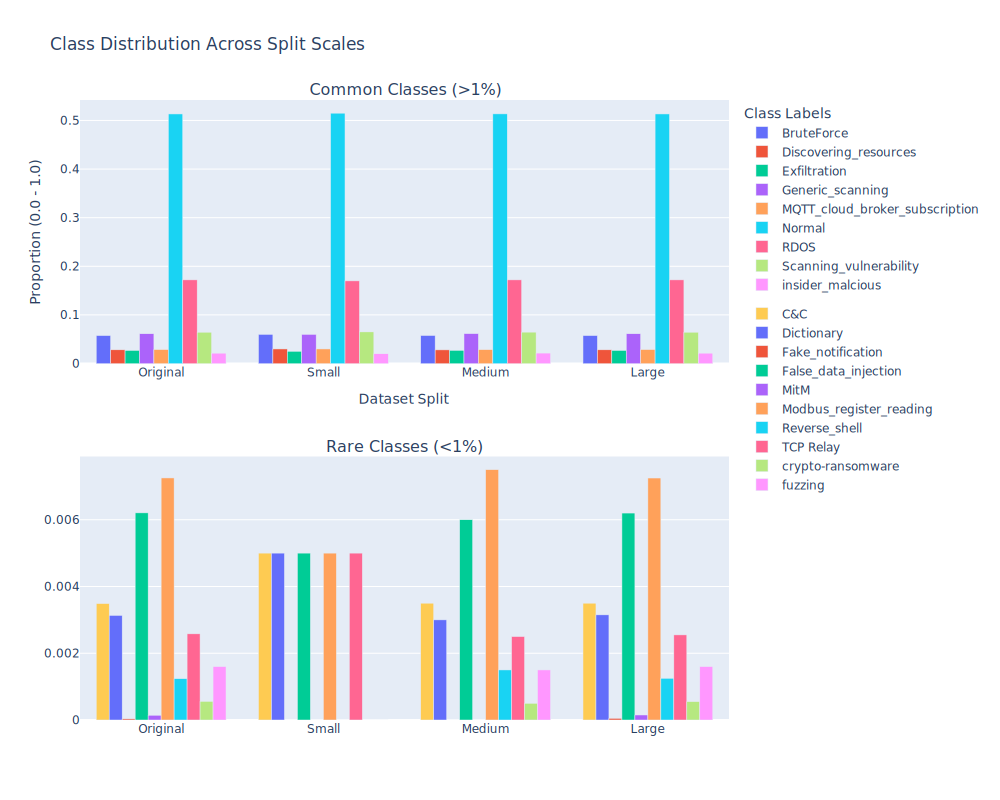

--- Detailed Distribution Table (class1) ---
                                Original (count)  Original (%)  Small Test Set (count)  Small Test Set (%)  Medium Test Set (count)  Medium Test Set (%)  Large Test Set (count)  Large Test Set (%)
BruteForce                                 47241       5.75524                    12.0                 6.0                    115.0                 5.75                    1151               5.755
C&C                                         2863       0.34879                     1.0                 0.5                      7.0                 0.35                      70               0.350
Dictionary                                  2572       0.31334                     1.0                 0.5                      6.0                 0.30                      63               0.315
Discovering_resources                      23148       2.82006                     6.0                 3.0                     56.0                 2.80               

In [18]:

from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import numpy as np
pio.renderers.default = "svg"
target_cols = ['class1', 'class2', 'class3']

X = df.drop(columns=target_cols)
y = df[['class1']]  # Focus on class1 for now


# Create the 1,000 row set
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X, y, train_size=800, test_size=200, stratify=y, random_state=42
)

# Create the 10,000 row set
X_train_med, X_test_med, y_train_med, y_test_med = train_test_split(
    X, y, train_size=8000, test_size=2000, stratify=y, random_state=42
)

# Create the 100,000 row set
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    X, y, train_size=80000, test_size=20000, stratify=y, random_state=42
)


labels = {i: label for i, label in enumerate(encoders['class1'].classes_)}

dataset_names = ['Original',
                 'Small',
                 'Medium',
                 'Large'
                 ]


def get_dist(series, labels_dict):
    # Get proportions and ensure all classes (0 to N) are present
    dist = series.value_counts(normalize=True).reindex(
        range(len(labels_dict)), fill_value=0)
    
    # Correctly map the integer index to string labels
    dist.index = [labels_dict[i] for i in dist.index]
    return dist


original_dist = get_dist(df['class1'], labels)
small_test_dist = get_dist(y_test_small['class1'], labels)
med_test_dist = get_dist(y_test_med['class1'], labels)
large_test_dist = get_dist(y_test_large['class1'], labels)

# Group distributions for iteration
all_dists = [original_dist,
             small_test_dist,
             med_test_dist,
             large_test_dist
             ]

threshold = 0.01
common_classes = original_dist[original_dist > threshold].index
rare_classes = original_dist[original_dist <= threshold].index

fig = make_subplots(rows=2, cols=1,
                    subplot_titles=("Common Classes (>1%)",
                                    "Rare Classes (<1%)"),
                    vertical_spacing=0.15)

# Add Common Classes to Legend
for cls in common_classes:
    y_vals = [d[cls] for d in all_dists]
    fig.add_trace(go.Bar(
        x=dataset_names,
        y=y_vals,
        name=str(cls),
        legendgroup="common"  # Optional: groups them in the legend
    ), row=1, col=1)

# Add Rare Classes to Legend
for cls in rare_classes:
    y_vals = [d[cls] for d in all_dists]
    fig.add_trace(go.Bar(
        x=dataset_names,
        y=y_vals,
        name=str(cls),
        legendgroup="rare"
    ), row=2, col=1)

# 5. Update Layout
fig.update_layout(
    width=1000,
    height=800,
    barmode='group',  # Set to 'stack' if you want to see total composition
    title="Class Distribution Across Split Scales",
    xaxis_title="Dataset Split",
    yaxis_title="Proportion (0.0 - 1.0)",
    legend_title="Class Labels",
    showlegend=True
)

fig.write_image("Data_Distribution_Legend.svg")
fig.show()

# --- Table Printing Logic ---
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)  # Ensure the width is large enough

orig_counts = df['class1'].value_counts()
orig_pcts = df['class1'].value_counts(normalize=True) * 100

# 2. Calculate counts and percentages for the Test Set
small_test_counts = y_test_small['class1'].value_counts()
small_test_pcts = y_test_small['class1'].value_counts(normalize=True) * 100
med_test_dist = y_test_med['class1'].value_counts()
med_test_pcts = y_test_med['class1'].value_counts(normalize=True) * 100
large_test_counts = y_test_large['class1'].value_counts()
large_test_pcts = y_test_large['class1'].value_counts(normalize=True) * 100

# 3. Combine into a single detailed DataFrame
comparison_table = pd.DataFrame({
    'Original (count)': orig_counts,
    'Original (%)': orig_pcts,
    'Small Test Set (count)': small_test_counts,
    'Small Test Set (%)': small_test_pcts,
    'Medium Test Set (count)': med_test_dist,
    'Medium Test Set (%)': med_test_pcts,
    'Large Test Set (count)': large_test_counts,
    'Large Test Set (%)': large_test_pcts
})


comparison_table.index = [labels[i] for i in comparison_table.index]

# 5. Clean up the display
print("--- Detailed Distribution Table (class1) ---")
print(comparison_table.round(5))

# Model Run

run GAN, Diffusion, and LLM then save to file, compare/view later


In [ ]:
import gc
from sklearn.experimental import enable_iterative_imputer
from tabgan.sampler import GANGenerator, LLMGenerator
import time
from datetime import datetime

categorical_features = [
    'Protocol', 'Service', 'Scr_IP',
    'Des_IP', 'Scr_port', 'Des_port', 
    'Conn_state', 'is_syn_only','Is_SYN_ACK',
    'is_pure_ack','is_with_payload','Bad_checksum',
    'is_SYN_with_RST','anomaly_alert','OSSEC_alert',
    'OSSEC_alert_level','Login_attempt','Succesful_login',
    'File_activity','Process_activity','is_privileged',
    'class1','class2','class3','FIN or RST',
    'read_write_physical.process']
cols = X.columns
filenames = {
    'Small GAN':'small_GAN_combined.csv',
    'Med GAN':'med_GAN_combined.csv',
    'Large GAN':'large_GAN_combined.csv',
    'Small Diffusion':'small_Diffusion_combined.csv',
    'Med Diffusion':'med_Diffusion_combined.csv',
    'Large Diffusion':'large_Diffusion_combined.csv',
    'Small LLM':'small_LLM_combined.csv',
    'Med LLM':'med_LLM_combined.csv',
    'Large LLM':'large_LLM_combined.csv',
    }
runtimes = {}
runtime_filename = 'runtimes_log.csv'

def save_and_clear(train,target, name, runtime):
    """Saves dataframe to disk and clears memory."""
    df_combined = pd.DataFrame(train, columns=cols)
    df_combined['class1'] = target
    df_combined.to_csv(filenames[name], index=False)
    del train, target, df_combined
    write_header = not os.path.exists(runtime_filename)
    df_runtime = pd.DataFrame({'Run_Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),'Model': [name], 'Runtime': [runtime]})
    df_runtime.to_csv(runtime_filename, mode='a', header=write_header, index=False)
    gc.collect()
    print(f"--- Saved {name}.csv and cleared memory ---")
    
# had to use help to make manual impl of diff otherwise it ran too slow
def DiffModel(x_train,y_train,name):
    start_time = time.time()
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import IterativeImputer
    from lightgbm import LGBMRegressor
    
    imputer = IterativeImputer(
        estimator=LGBMRegressor(n_estimators=100, device='gpu'),
        max_iter=10,
        random_state=42
    )

    train_pd = pd.concat([x_train, y_train], axis=1)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_pd)
    train_scaled_df = pd.DataFrame(train_scaled, columns=train_pd.columns)

    X_noise_template = train_scaled_df.copy()
    noise = np.random.normal(0, 1, size=X_noise_template.shape)
    X_noise_template = (X_noise_template * 0.5) + (noise * 0.5)
    
    X_noise_template = pd.DataFrame(X_noise_template, columns=train_pd.columns)
    
    imputer.fit(train_scaled_df)
    X_synthetic = imputer.transform(X_noise_template)

    X_synthetic_final_array = scaler.inverse_transform(X_synthetic)
    
    X_synthetic_df = pd.DataFrame(X_synthetic_final_array, columns=train_pd.columns)
    for col, le in encoders.items():
        if col in X_synthetic_df.columns:
            min_val = 0
            max_val = len(le.classes_) - 1
            X_synthetic_df[col] = X_synthetic_df[col].round().clip(min_val, max_val).astype(int)
    runtime = time.time() - start_time
    
    X_synthetic_df.clip(lower=0).to_csv(filenames[name], index=False)
    write_header = not os.path.exists(runtime_filename)
    df_runtime = pd.DataFrame({'Run_Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),'Model': [name], 'Runtime': [runtime]})
    df_runtime.to_csv(runtime_filename, mode='a', header=write_header, index=False)
    gc.collect()
    print(f"--- Saved {name}.csv and cleared memory ---")


In [6]:
gc.collect()
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
start_time = time.time()
small_GAN_train, small_GAN_target = GANGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 50, "patience": 15, "epochs": 300, "gen_x_times": 1.1}) \
    .generate_data_pipe(train_df=X_train_small, target=y_train_small, test_df=X_test_small)
save_and_clear(small_GAN_train, small_GAN_target, 'Small GAN', time.time() - start_time)

start_time = time.time()
med_GAN_train, med_GAN_target = GANGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 260, "patience": 25, "epochs": 300, "gen_x_times": 1.1}) \
    .generate_data_pipe(train_df=X_train_med, target=y_train_med, test_df=X_test_med)
save_and_clear(med_GAN_train, med_GAN_target, 'Med GAN', time.time() - start_time)

start_time = time.time()
large_GAN_train, large_GAN_target = GANGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 500, "patience": 25, "epochs": 300, "gen_x_times": 1.1}) \
    .generate_data_pipe(train_df=X_train_large, target=y_train_large, test_df=X_test_large)
save_and_clear(large_GAN_train, large_GAN_target, 'Large GAN', time.time() - start_time)


Fitting CTGAN transformers for each column:   0%|          | 0/65 [00:00<?, ?it/s]

Training CTGAN, epochs::   0%|          | 0/300 [00:00<?, ?it/s]

--- Saved Small GAN.csv and cleared memory ---


Fitting CTGAN transformers for each column:   0%|          | 0/65 [00:00<?, ?it/s]

Training CTGAN, epochs::   0%|          | 0/300 [00:00<?, ?it/s]

--- Saved Med GAN.csv and cleared memory ---


Fitting CTGAN transformers for each column:   0%|          | 0/65 [00:00<?, ?it/s]

Training CTGAN, epochs::   0%|          | 0/300 [00:00<?, ?it/s]

--- Saved Large GAN.csv and cleared memory ---


In [17]:

DiffModel(X_train_small,y_train_small,'Small Diffusion')
DiffModel(X_train_med,y_train_med,'Med Diffusion')
DiffModel(X_train_large,y_train_large,'Large Diffusion')


--- Saved Small Diffusion.csv and cleared memory ---
--- Saved Med Diffusion.csv and cleared memory ---
--- Saved Large Diffusion.csv and cleared memory ---


In [ ]:
gc.collect()
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
start_time = time.time()
small_LLM_train, small_LLM_target = LLMGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 16, "patience": 5, "epochs": 30, "device": "cuda", "fp16": True,
    "llm": "distilgpt2", "max_length": 256, "gen_x_times": 1.1}) \
    .generate_data_pipe(train_df=X_train_small, target=y_train_small, test_df=X_test_small)
save_and_clear(small_LLM_train, small_LLM_target, 'Small LLM', time.time() - start_time)

gc.collect()
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
torch.cuda.empty_cache()
start_time = time.time()
med_LLM_train, med_LLM_target = LLMGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 16, "patience": 3, "epochs": 10, "device": "cuda", "fp16": True,
    "llm": "distilgpt2", "max_length": 256, "gen_x_times": 1.1}) \
    .generate_data_pipe(train_df=X_train_med, target=y_train_med, test_df=X_test_med.astype('float32'))
save_and_clear(med_LLM_train, med_LLM_target, 'Med LLM', time.time() - start_time)

gc.collect()
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
torch.cuda.empty_cache()
start_time = time.time()
large_LLM_train, large_LLM_target = LLMGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 16, "patience": 2, "epochs": 2, "device": "cuda", "fp16": True,
    "llm": "distilgpt2", "max_length": 256, "gen_x_times": 1.1}) \
    .generate_data_pipe(train_df=X_train_large, target=y_train_large, test_df=X_test_large)
save_and_clear(large_LLM_train, large_LLM_target, 'Large LLM', time.time() - start_time)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Step,Training Loss
500,1.623598
1000,1.274387
1500,1.211613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Unable to generate samples after 14 attempts.
To address this issue, consider using guided_sampling=True, which uses a different generation approach that may be more reliable, although it might be much slower.
Example: model.sample(n_samples=10, guided_sampling=True)
An error has occurred: Breaking the generation loop!
To address this issue, consider fine-tuning the GReaT model for a longer period. This can be achieved by increasing the number of epochs.
Alternatively, you might consider increasing the max_length parameter within the sample function. For example: model.sample(n_samples=10, max_length=2000)
You can also try using guided_sampling=True, which uses a different generation approach that may be more reliable, although it might be slower. For example: model.sample(n_samples=10, guided_sampling=True)
If the problem persists despite these adjustments, feel free to raise an issue on our GitHub page at: https://github.com/kathrinse/be_great/issues
--- Saved Med LLM.csv and cleared

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Step,Training Loss


KeyboardInterrupt: 